## 11. Diferentes variables requieren diferentes reglas de agregación

Cuando un conjunto de datos contiene varias variables, no es correcto aplicar automáticamente la misma función de agregación a todas ellas.

Supongamos que en cada día $t$ observamos:

$$
\mathbf{X}_t =
\left(
T_t,
P_t,
C_t
\right),
$$

donde:

- $T_t$ es temperatura;
- $P_t$ es precipitación;
- $C_t$ es número de casos.

Si queremos construir una serie semanal, las tres variables representan cantidades de naturaleza diferente.


### Temperatura

Para describir el nivel térmico de una semana puede ser razonable calcular

$$
\overline{T}_w
=
\frac{1}{n_w}
\sum_{t\in w}T_t.
$$

También puede ser relevante conservar

$$
T^{\max}_w
=
\max_{t\in w}T_t
$$

si estamos interesados en episodios de calor extremo.



### Precipitación

La precipitación diaria representa una cantidad acumulada durante un periodo.

Por tanto, para conocer la precipitación total semanal es natural calcular

$$
P_w
=
\sum_{t\in w}P_t.
$$

Utilizar la media respondería a una pregunta diferente: precipitación diaria promedio durante la semana.



### Número de casos

Si $C_t$ representa el número de casos registrados cada día, el total semanal corresponde a

$$
C_w
=
\sum_{t\in w}C_t.
$$

Promediar el número de casos diarios produciría una variable distinta y no equivaldría a la incidencia semanal total.



### Una misma base puede requerir varias funciones de agregación

Por ejemplo, al pasar de datos diarios a semanales podríamos utilizar simultáneamente:

| Variable | Agregación semanal |
|---|---|
| Temperatura | media |
| Temperatura | máximo |
| Humedad relativa | media |
| Precipitación | suma |
| Casos | suma |
| $O_3$ | máximo |
| $PM_{2.5}$ | media |

En `pandas`, el método `.agg()` permite asignar una función distinta a cada variable.

Esta decisión debe realizarse **antes de construir el dataset final de análisis**, porque la agregación modifica el significado de cada columna.

In [25]:
# Ejemplo multivariado: temperatura, precipitación y número de casos

rng = np.random.default_rng(123)

fechas_multi = pd.date_range(
    start="2026-01-01",
    periods=56,
    freq="D"
)

datos_multivariados = pd.DataFrame(
    {
        "temperatura": (
            18
            + 3 * np.sin(np.arange(len(fechas_multi)) * 2 * np.pi / 28)
            + rng.normal(0, 1, len(fechas_multi))
        ),

        "precipitacion": rng.gamma(
            shape=1.2,
            scale=4,
            size=len(fechas_multi)
        ),

        "casos": rng.poisson(
            lam=5,
            size=len(fechas_multi)
        )
    },
    index=fechas_multi
)

datos_multivariados.index.name = "fecha"


datos_multivariados

,temperatura,precipitacion,casos
fecha,,,
2026-01-01,17.010879,1.145265,8
2026-01-02,18.299776,4.336145,4
2026-01-03,20.589576,1.812095,8
2026-01-04,20.064444,2.416653,1
2026-01-05,21.265725,0.397287,3
2026-01-06,21.280010,5.371838,4
2026-01-07,20.288320,4.695198,8
2026-01-08,21.541952,2.736784,5
2026-01-09,20.608188,8.363889,6


In [26]:
# Agregación semanal

datos_semanales = (
    datos_multivariados
    .resample("W-SUN")
    .agg(
        temperatura_media=("temperatura", "mean"),
        temperatura_maxima=("temperatura", "max"),
        precipitacion_total=("precipitacion", "sum"),
        casos_totales=("casos", "sum")
    )
)

datos_semanales.round(2)

,temperatura_media,temperatura_maxima,precipitacion_total,casos_totales
fecha,,,,
2026-01-04,18.99,20.59,9.71,21
2026-01-11,20.83,21.54,37.95,39
2026-01-18,18.14,20.49,29.36,31
2026-01-25,15.59,16.62,30.57,34
2026-02-01,18.15,18.94,34.56,33
2026-02-08,21.06,22.46,45.30,40
2026-02-15,17.88,20.03,45.06,43
2026-02-22,15.47,17.37,24.08,44
2026-03-01,16.38,16.75,16.19,20


## 12. Alineación temporal de diferentes fuentes de datos

En aplicaciones reales es común que las variables de interés provengan de fuentes distintas.

Por ejemplo, un estudio epidemiológico podría combinar:

- casos de dengue registrados semanalmente;
- temperatura diaria;
- precipitación diaria;
- humedad relativa diaria.

De manera similar, un estudio de contaminación puede combinar:

- concentraciones horarias de contaminantes;
- variables meteorológicas horarias;
- información diaria o mensual proveniente de otra fuente.

Antes de analizar conjuntamente estas variables debemos asegurarnos de que estén **temporalmente alineadas**.


### Dos series pueden cubrir periodos diferentes

Supongamos que tenemos dos series:

$$
X_t,\qquad t\in\mathcal{T}_X,
$$

y

$$
Y_t,\qquad t\in\mathcal{T}_Y.
$$

No necesariamente se cumple que

$$
\mathcal{T}_X=\mathcal{T}_Y.
$$

Por ejemplo, una serie meteorológica puede comenzar antes que una serie epidemiológica o contener fechas para las cuales no existen registros de la otra variable.

Podemos considerar dos conjuntos temporales importantes.

### Intersección temporal

$$
\mathcal{T}_{\cap}
=
\mathcal{T}_X\cap\mathcal{T}_Y.
$$

Contiene únicamente las fechas presentes en ambas fuentes.

### Unión temporal

$$
\mathcal{T}_{\cup}
=
\mathcal{T}_X\cup\mathcal{T}_Y.
$$

Contiene todas las fechas presentes en cualquiera de las fuentes.



### `inner join`

Un `inner join` conserva únicamente la intersección:

$$
\mathcal{T}_{\cap}.
$$

Es útil cuando necesitamos observaciones completas para todas las variables, aunque puede provocar pérdida de información.



### `outer join`

Un `outer join` conserva la unión:

$$
\mathcal{T}_{\cup}.
$$

Las fechas para las cuales alguna fuente no tiene información aparecen explícitamente como valores faltantes.

Esto suele ser útil durante la etapa de diagnóstico porque permite observar dónde existen problemas de cobertura.



### Antes de combinar datos debemos homologar la frecuencia

No es correcto unir directamente, por ejemplo, una serie diaria de temperatura con una serie semanal de casos y asumir que cada observación representa el mismo periodo.

Primero debemos decidir una frecuencia común:

$$
\boxed{
\text{Fuente A}
\longrightarrow
\text{frecuencia común}
\longleftarrow
\text{Fuente B}
}
$$

y definir una regla de agregación apropiada para cada variable.

A continuación simularemos dos fuentes con diferentes periodos de cobertura y veremos la diferencia entre conservar la unión y la intersección temporal.

In [27]:
rng = np.random.default_rng(2026)

# Fuente 1: temperatura diaria
fechas_temperatura = pd.date_range(
    start="2026-01-01",
    end="2026-01-20",
    freq="D"
)

df_temperatura = pd.DataFrame(
    {
        "temperatura": (
            18
            + rng.normal(0, 2, len(fechas_temperatura))
        )
    },
    index=fechas_temperatura
)

df_temperatura.index.name = "fecha"
df_temperatura

,temperatura
fecha,
2026-01-01,16.413755
2026-01-02,18.481143
2026-01-03,14.207347
2026-01-04,20.791543
2026-01-05,19.276589
2026-01-06,17.415905
2026-01-07,17.376101
2026-01-08,18.607671
2026-01-09,17.464679


In [28]:
# Fuente 2: humedad diaria, pero con un periodo diferente
fechas_humedad = pd.date_range(
    start="2026-01-06",
    end="2026-01-25",
    freq="D"
)

df_humedad = pd.DataFrame(
    {
        "humedad": (
            60
            + rng.normal(0, 8, len(fechas_humedad))
        )
    },
    index=fechas_humedad
)

df_humedad.index.name = "fecha"

df_humedad

,humedad
fecha,
2026-01-06,56.181770
2026-01-07,65.252973
2026-01-08,58.141738
2026-01-09,58.810138
2026-01-10,65.134693
2026-01-11,74.596882
2026-01-12,54.294491
2026-01-13,70.785655
2026-01-14,50.159898


In [29]:
print("Cobertura de temperatura:")
print(df_temperatura.index.min(), "a", df_temperatura.index.max())

print("\nCobertura de humedad:")
print(df_humedad.index.min(), "a", df_humedad.index.max())

Cobertura de temperatura:
2026-01-01 00:00:00 a 2026-01-20 00:00:00

Cobertura de humedad:
2026-01-06 00:00:00 a 2026-01-25 00:00:00


In [30]:
# INNER JOIN: únicamente fechas presentes en ambas fuentes

datos_inner = df_temperatura.join(
    df_humedad,
    how="inner"
)

print("\nINNER JOIN:")
display(datos_inner)

print(
    "Número de fechas conservadas:",
    len(datos_inner)
)


INNER JOIN:


,temperatura,humedad
fecha,,
2026-01-06,17.415905,56.181770
2026-01-07,17.376101,65.252973
2026-01-08,18.607671,58.141738
2026-01-09,17.464679,58.810138
2026-01-10,17.548182,65.134693
2026-01-11,19.440136,74.596882
2026-01-12,19.029410,54.294491
2026-01-13,17.871744,70.785655
2026-01-14,17.829047,50.159898


Número de fechas conservadas: 15


In [31]:
# OUTER JOIN: todas las fechas de ambas fuentes

datos_outer = df_temperatura.join(
    df_humedad,
    how="outer"
)

print("\nOUTER JOIN:")
display(datos_outer)

print(
    "Número de fechas conservadas:",
    len(datos_outer)
)


OUTER JOIN:


,temperatura,humedad
fecha,,
2026-01-01,16.413755,NaN
2026-01-02,18.481143,NaN
2026-01-03,14.207347,NaN
2026-01-04,20.791543,NaN
2026-01-05,19.276589,NaN
2026-01-06,17.415905,56.181770
2026-01-07,17.376101,65.252973
2026-01-08,18.607671,58.141738
2026-01-09,17.464679,58.810138


Número de fechas conservadas: 25


In [32]:
# Diagnóstico de valores faltantes

print("\nValores faltantes después del OUTER JOIN:")
display(datos_outer.isna().sum())

print("\nFechas con información incompleta:")
display(
    datos_outer[
        datos_outer.isna().any(axis=1)
    ]
)


Valores faltantes después del OUTER JOIN:


temperatura    5
humedad        5
dtype: int64


Fechas con información incompleta:


,temperatura,humedad
fecha,,
2026-01-01,16.413755,NaN
2026-01-02,18.481143,NaN
2026-01-03,14.207347,NaN
2026-01-04,20.791543,NaN
2026-01-05,19.276589,NaN
2026-01-21,NaN,65.476440
2026-01-22,NaN,55.847893
2026-01-23,NaN,56.340918
2026-01-24,NaN,64.052297


## 13. Integración de fuentes con diferentes frecuencias temporales

En la práctica, dos fuentes de datos pueden tener no solamente periodos de cobertura diferentes, sino también **frecuencias temporales distintas**.

Por ejemplo, supongamos que disponemos de:

- casos de dengue registrados semanalmente;
- temperatura diaria;
- precipitación diaria.

La variable epidemiológica está definida como

$$
C_w,
$$

donde $w$ representa una semana, mientras que las variables meteorológicas están disponibles diariamente:

$$
T_t,
\qquad
P_t.
$$

No podemos relacionar directamente una observación semanal con una observación diaria, porque representan escalas temporales distintas.

Antes de combinar las fuentes debemos construir covariables meteorológicas que representen la misma semana.


### Temperatura semanal

Una posibilidad es utilizar la temperatura media semanal:

$$
\overline{T}_w
=
\frac{1}{n_w}
\sum_{t\in w}T_t.
$$

También podría interesarnos la temperatura máxima:

$$
T^{\max}_w
=
\max_{t\in w}T_t.
$$



### Precipitación semanal

Si $P_t$ representa la precipitación acumulada durante el día $t$, entonces la precipitación semanal puede definirse como

$$
P_w
=
\sum_{t\in w}P_t.
$$

De esta forma, construimos para cada semana un vector de covariables:

$$
\mathbf{X}_w
=
\left(
\overline{T}_w,
T^{\max}_w,
P_w
\right),
$$

que posteriormente puede relacionarse con la variable de interés:

$$
C_w.
$$

El conjunto final tendrá entonces la estructura

$$
\left\{
(C_w,\mathbf{X}_w)
\right\}_{w=1}^{W}.
$$


### Principio general

Cuando integramos fuentes con frecuencias diferentes, el procedimiento adecuado es:

$$
\boxed{
\begin{array}{ccc}
\text{Fuente diaria}
& \longrightarrow &
\text{Agregación semanal}
\\
&& \downarrow
\\
\text{Fuente semanal}
& \longrightarrow &
\text{Alineación temporal}
\end{array}
}
$$

La agregación debe realizarse **antes** de unir las fuentes.

Además, debemos asegurarnos de que ambas series utilicen exactamente la misma definición de semana. Por ejemplo, si los casos están etiquetados al final de semanas que terminan en domingo, las variables meteorológicas deben construirse utilizando esa misma convención.

A continuación simularemos este procedimiento.

In [33]:
rng = np.random.default_rng(2026)

# 1. Datos meteorológicos diarios

fechas_diarias = pd.date_range(
    start="2026-01-01",
    end="2026-02-28",
    freq="D"
)

meteorologia_diaria = pd.DataFrame(
    {
        "temperatura": (
            20
            + 3 * np.sin(
                np.arange(len(fechas_diarias)) * 2 * np.pi / 30
            )
            + rng.normal(0, 1, len(fechas_diarias))
        ),
        "precipitacion": rng.gamma(
            shape=1.2,
            scale=3,
            size=len(fechas_diarias)
        )
    },
    index=fechas_diarias
)

meteorologia_diaria.index.name = "fecha"
meteorologia_diaria

,temperatura,precipitacion
fecha,,
2026-01-01,19.206878,1.336544
2026-01-02,20.864306,0.684402
2026-01-03,19.323884,0.301383
2026-01-04,23.159127,8.142594
2026-01-05,22.867729,3.386195
2026-01-06,22.306029,3.103172
2026-01-07,22.541220,1.096021
2026-01-08,23.287401,1.288061
2026-01-09,22.715905,4.089218


In [34]:
# 2. Construcción de covariables meteorológicas semanales

meteorologia_semanal = (
    meteorologia_diaria
    .resample("W-SUN")
    .agg(
        temperatura_media=("temperatura", "mean"),
        temperatura_maxima=("temperatura", "max"),
        precipitacion_total=("precipitacion", "sum")
    )
)

meteorologia_semanal

,temperatura_media,temperatura_maxima,precipitacion_total
fecha,,,
2026-01-04,20.638549,23.159127,10.464923
2026-01-11,22.809098,23.318144,16.268973
2026-01-18,20.578471,22.744140,13.998726
2026-01-25,17.238703,18.106161,25.267123
2026-02-01,19.110778,21.975193,34.442480
2026-02-08,22.561740,23.490103,41.247783
2026-02-15,21.953330,23.729888,34.478629
2026-02-22,19.226877,21.559753,30.240926
2026-03-01,18.027301,20.067868,40.882828


In [35]:
# 3. Simulación de casos semanales

fechas_semanales = meteorologia_semanal.index

casos_semanales = pd.DataFrame(
    {
        "casos": rng.poisson(
            lam=12,
            size=len(fechas_semanales)
        )
    },
    index=fechas_semanales
)

casos_semanales.index.name = "fecha"
casos_semanales

,casos
fecha,
2026-01-04,14
2026-01-11,8
2026-01-18,12
2026-01-25,13
2026-02-01,17
2026-02-08,10
2026-02-15,15
2026-02-22,9
2026-03-01,6


In [36]:
# 4. Integración de ambas fuentes

datos_integrados = casos_semanales.join(
    meteorologia_semanal,
    how="inner"
)

print("\nDataset semanal integrado:")
datos_integrados.round(2)


Dataset semanal integrado:


,casos,temperatura_media,temperatura_maxima,precipitacion_total
fecha,,,,
2026-01-04,14,20.64,23.16,10.46
2026-01-11,8,22.81,23.32,16.27
2026-01-18,12,20.58,22.74,14.00
2026-01-25,13,17.24,18.11,25.27
2026-02-01,17,19.11,21.98,34.44
2026-02-08,10,22.56,23.49,41.25
2026-02-15,15,21.95,23.73,34.48
2026-02-22,9,19.23,21.56,30.24
2026-03-01,6,18.03,20.07,40.88


In [37]:
# 5. Comprobación de la estructura temporal

print("\nFrecuencia del dataset final:")
print(pd.infer_freq(datos_integrados.index))

print("\nNúmero de valores faltantes:")
display(datos_integrados.isna().sum())


Frecuencia del dataset final:
W-SUN

Número de valores faltantes:


casos                  0
temperatura_media      0
temperatura_maxima     0
precipitacion_total    0
dtype: int64

## 14. Fechas duplicadas y definición de la unidad de observación

Hasta ahora hemos trabajado con series en las que cada fecha aparece una sola vez. Sin embargo, en datos reales es frecuente encontrar varias filas asociadas con la misma fecha.

Esto no necesariamente representa un error.

Por ejemplo, podemos tener observaciones de contaminación provenientes de distintas estaciones:

| fecha | estación | $O_3$ |
|---|---|---:|
| 2026-01-01 | A | 42 |
| 2026-01-01 | B | 51 |
| 2026-01-01 | C | 38 |

En este caso, la fecha se repite porque la verdadera unidad de observación es

$$
(\text{estación},t).
$$

De manera similar, para datos epidemiológicos podríamos tener

$$
(\text{estado},t),
$$

o

$$
(\text{municipio},t).
$$

Por tanto, antes de eliminar registros aparentemente duplicados debemos preguntarnos: **¿Qué combinación de variables identifica de manera única una observación?**



### Duplicados reales y observaciones repetidas válidas

Supongamos que una base contiene las variables

$$
Y_{i,t},
$$

donde $i$ identifica una región y $t$ una fecha.

La combinación

$$
(i,t)
$$

debería identificar de manera única cada observación.

Si aparecen dos registros con exactamente el mismo par

$$
(i,t),
$$

entonces sí debemos investigar si se trata de:

- un duplicado generado durante la integración de datos;
- mediciones repetidas;
- diferentes instrumentos;
- diferentes horarios dentro del mismo periodo;
- un error en la base.




In [41]:
# Ejemplo de datos tipo panel: varias regiones observadas en las mismas fechas

fechas_panel = pd.date_range(
    start="2026-01-01",
    periods=7,
    freq="D"
)

regiones = ["Norte", "Centro", "Sur"]

panel = pd.MultiIndex.from_product(
    [regiones, fechas_panel],
    names=["region", "fecha"]
).to_frame(index=False)

rng = np.random.default_rng(2026)

panel["temperatura"] = rng.normal(
    loc=20,
    scale=3,
    size=len(panel)
)

panel["casos"] = rng.poisson(
    lam=5,
    size=len(panel)
)

panel

,region,fecha,temperatura,casos
0,Norte,2026-01-01,17.620633,2
1,Norte,2026-01-02,20.721714,5
2,Norte,2026-01-03,14.311021,8
3,Norte,2026-01-04,24.187315,5
4,Norte,2026-01-05,21.914884,6
5,Norte,2026-01-06,19.123858,6
6,Norte,2026-01-07,19.064152,4
7,Centro,2026-01-01,20.911506,5
8,Centro,2026-01-02,19.197019,8
9,Centro,2026-01-03,19.322273,4


In [42]:
# Diagnóstico de la unidad de observación

print("Número total de filas:")
print(len(panel))

print("\nNúmero de fechas distintas:")
print(panel["fecha"].nunique())

print("\nNúmero de regiones:")
print(panel["region"].nunique())

Número total de filas:
21

Número de fechas distintas:
7

Número de regiones:
3


In [40]:
# ¿Existen pares region-fecha duplicados?

duplicados = panel.duplicated(
    subset=["region", "fecha"],
    keep=False
)

print("\nNúmero de observaciones con combinación "
      "region-fecha duplicada:")
duplicados.sum()


Número de observaciones con combinación region-fecha duplicada:


0

In [43]:
# Número de observaciones por región

print("\nObservaciones por región:")
display(
    panel.groupby("region")
         .size()
         .rename("n_observaciones")
)


Observaciones por región:


region
Centro    7
Norte     7
Sur       7
Name: n_observaciones, dtype: int64

In [44]:
# Construcción de un índice compuesto

panel_indexado = (
    panel
    .set_index(["region", "fecha"])
    .sort_index()
)

print("\nPanel con índice compuesto (region, fecha):")
display(panel_indexado.head(10))

print("\n¿El índice compuesto es único?")
print(panel_indexado.index.is_unique)


Panel con índice compuesto (region, fecha):


temperatura  casos
region fecha                         
Centro 2026-01-01    20.911506      5
       2026-01-02    19.197019      8
       2026-01-03    19.322273      4
       2026-01-04    22.160203      2
       2026-01-05    21.544116     11
       2026-01-06    19.807616      6
       2026-01-07    19.743570      7
Norte  2026-01-01    17.620633      2
       2026-01-02    20.721714      5
       2026-01-03    14.311021      8


¿El índice compuesto es único?
True


## 15. Paneles balanceados y no balanceados

Cuando trabajamos con varias unidades observadas a lo largo del tiempo, no siempre todas las unidades tienen información para todas las fechas.

Supongamos un panel

$$
Y_{i,t},
$$

donde:

- $i=1,\ldots,N$ identifica la unidad;
- $t=1,\ldots,T$ identifica el tiempo.

Un **panel balanceado** contiene una observación para cada combinación posible

$$
(i,t).
$$

En ese caso, el número total esperado de observaciones es

$$
N_{\text{esperado}}=N\times T.
$$

Por ejemplo, si tenemos $3$ regiones observadas durante $7$ días, esperamos

$$
3\times7=21
$$

combinaciones región--fecha.



### Panel no balanceado

Un panel es **no balanceado** cuando una o más unidades carecen de observaciones en ciertos periodos.

Por ejemplo:

$$
\begin{array}{c|cccc}
 & t_1 & t_2 & t_3 & t_4\\
\hline
A & \checkmark & \checkmark & \checkmark & \checkmark\\
B & \checkmark & \checkmark & \times & \checkmark\\
C & \checkmark & \times & \checkmark & \checkmark
\end{array}
$$

Las ausencias pueden deberse a:

- fallas de medición;
- estaciones que comienzan a operar en fechas diferentes;
- registros epidemiológicos incompletos;
- problemas al integrar diferentes bases de datos;
- filtros aplicados durante el preprocesamiento.



### ¿Cómo detectar las combinaciones faltantes?

Podemos construir todas las combinaciones teóricamente esperadas:

$$
\mathcal{I}\times\mathcal{T},
$$

donde $\mathcal{I}$ es el conjunto de unidades y $\mathcal{T}$ el conjunto de fechas.

Posteriormente comparamos ese conjunto con las combinaciones realmente observadas.



In [47]:
# Ejemplo de panel no balanceado

panel_incompleto = panel.copy()

# Eliminamos algunas combinaciones
panel_incompleto = panel_incompleto[
    ~(
        ((panel_incompleto["region"] == "Centro") &
         (panel_incompleto["fecha"] == "2026-01-03"))
        |
        ((panel_incompleto["region"] == "Sur") &
         (panel_incompleto["fecha"] == "2026-01-05"))
    )
].copy()

print("Número de observaciones originales:")
print(len(panel))



print("\nNúmero de observaciones después de eliminar registros:")
print(len(panel_incompleto))

Número de observaciones originales:
21

Número de observaciones después de eliminar registros:
19


In [44]:
panel

,region,fecha,temperatura,casos
0,Norte,2026-01-01,17.620633,2
1,Norte,2026-01-02,20.721714,5
2,Norte,2026-01-03,14.311021,8
3,Norte,2026-01-04,24.187315,5
4,Norte,2026-01-05,21.914884,6
5,Norte,2026-01-06,19.123858,6
6,Norte,2026-01-07,19.064152,4
7,Centro,2026-01-01,20.911506,5
8,Centro,2026-01-02,19.197019,8
9,Centro,2026-01-03,19.322273,4


In [48]:
# Número esperado de combinaciones region-fecha

n_regiones = panel_incompleto["region"].nunique()

fecha_min = panel_incompleto["fecha"].min()
fecha_max = panel_incompleto["fecha"].max()

calendario_panel = pd.date_range(
    start=fecha_min,
    end=fecha_max,
    freq="D"
)

n_esperado = n_regiones * len(calendario_panel)

print("\nNúmero esperado de combinaciones región-fecha:")
print(n_esperado)

print("\nNúmero observado:")
print(len(panel_incompleto))

print("\nNúmero de combinaciones faltantes:")
print(n_esperado - len(panel_incompleto))


Número esperado de combinaciones región-fecha:
21

Número observado:
19

Número de combinaciones faltantes:
2


In [50]:
# Construcción del índice completo

indice_completo = pd.MultiIndex.from_product( # Toma dos o más listas/iterables y genera todas las combinaciones posibles entre sus elementos.
    [
        sorted(panel_incompleto["region"].unique()),
        calendario_panel
    ],
    names=["region", "fecha"]
)

panel_balanceado = (
    panel_incompleto
    .set_index(["region", "fecha"])
    .reindex(indice_completo)
)

panel_balanceado

temperatura  casos
region fecha                         
Centro 2026-01-01    20.911506    5.0
       2026-01-02    19.197019    8.0
       2026-01-03          NaN    NaN
       2026-01-04    22.160203    2.0
       2026-01-05    21.544116   11.0
       2026-01-06    19.807616    6.0
       2026-01-07    19.743570    7.0
Norte  2026-01-01    17.620633    2.0
       2026-01-02    20.721714    5.0
       2026-01-03    14.311021    8.0
       2026-01-04    24.187315    5.0
       2026-01-05    21.914884    6.0
       2026-01-06    19.123858    6.0
       2026-01-07    19.064152    4.0
Sur    2026-01-01    20.482749    2.0
       2026-01-02    18.157945    6.0
       2026-01-03    18.788749    5.0
       2026-01-04    21.644781   10.0
       2026-01-05          NaN    NaN
       2026-01-06    15.876721    2.0
       2026-01-07    18.568164    6.0

In [52]:
# Identificación de las combinaciones faltantes

filas_faltantes = panel_balanceado[
    panel_balanceado.isna().all(axis=1)
]

print("\nCombinaciones región-fecha que no estaban en los datos:")
display(filas_faltantes)



Combinaciones región-fecha que no estaban en los datos:


,,temperatura,casos
region,fecha,,
Centro,2026-01-03,NaN,NaN
Sur,2026-01-05,NaN,NaN


## 16. Medición de cobertura temporal por unidad

Una vez que hemos identificado si un panel está balanceado o no, conviene cuantificar **qué tan completa es la información disponible para cada unidad**.

Supongamos que para una unidad $i$ esperamos observar $T$ periodos, pero únicamente contamos con $T_i$ registros válidos.

Podemos definir la cobertura temporal como

$$
\text{Cobertura}_i
=
\frac{T_i}{T}\times 100.
$$

Por ejemplo, si una estación debería tener $365$ observaciones diarias y solamente dispone de $300$, entonces

$$
\text{Cobertura}
=
\frac{300}{365}\times 100
\approx 82.2\%.
$$

---

### ¿Por qué es importante la cobertura?

Dos unidades pueden pertenecer al mismo panel, pero tener calidad temporal muy distinta.

Por ejemplo:

| Unidad | Observaciones esperadas | Observaciones disponibles | Cobertura |
|---|---:|---:|---:|
| A | 365 | 360 | 98.6\% |
| B | 365 | 250 | 68.5\% |
| C | 365 | 120 | 32.9\% |

Aunque las tres unidades aparecen en la base, no necesariamente deberían recibir el mismo tratamiento.

Una cobertura baja puede afectar:

- cálculo de tendencias;
- estimación de estacionalidad;
- correlaciones;
- construcción de rezagos;
- clustering;
- modelos predictivos;
- comparación entre regiones o estaciones.


### Cobertura estructural y cobertura de una variable

Es útil distinguir dos conceptos.

#### Cobertura estructural

Indica si existe una fila para la combinación unidad--tiempo.

#### Cobertura de una variable

Indica si una variable específica contiene un valor válido.

Por ejemplo, una estación puede tener registros para todos los días, pero `temperatura` puede estar disponible en el $98\%$ de ellos y `precipitacion` únicamente en el $80\%$.

Por tanto, la cobertura también puede calcularse por variable:

$$
\text{Cobertura}_{i,j}
=
\frac{
\#\{\text{valores no faltantes de la variable }j\text{ en }i\}
}{
T
}
\times100.
$$

En datos reales, esta revisión permite establecer posteriormente criterios mínimos de inclusión, por ejemplo conservar solamente unidades con al menos un cierto porcentaje de cobertura temporal.

In [53]:
panel_cobertura = panel_balanceado.copy()

# fechas esperadas por región
n_fechas_esperadas = len(calendario_panel)

# Cobertura estructural: contamos filas que tienen al menos algún dato disponible

cobertura_region = (
    panel_cobertura
    .groupby(level="region")
    .apply(lambda x: x.notna().any(axis=1).sum()) #x.notna(): Evalúa cada celda y marca con True si no es un valor nulo y .any(axis=1): Evalúa horizontalmente por fila.
    .rename("n_observaciones")
    .to_frame()
)

cobertura_region["n_esperadas"] = n_fechas_esperadas

cobertura_region["cobertura_pct"] = (
    cobertura_region["n_observaciones"]
    / cobertura_region["n_esperadas"]
    * 100
)

print("Cobertura temporal por región:")
cobertura_region.round(2)

Cobertura temporal por región:


,n_observaciones,n_esperadas,cobertura_pct
region,,,
Centro,6,7,85.71
Norte,7,7,100.00
Sur,6,7,85.71


In [56]:
# Cobertura por variable y región

cobertura_variables = (
    panel_cobertura
    .groupby(level="region")
    .apply(lambda x: x.notna().sum())
)

cobertura_variables_pct = (
    cobertura_variables
    / n_fechas_esperadas
    * 100
)

print("\nCobertura por variable y región (%):")
cobertura_variables_pct.round(2)


Cobertura por variable y región (%):


,temperatura,casos
region,,
Centro,85.71,85.71
Norte,100.00,100.00
Sur,85.71,85.71


In [58]:
# Identificación de regiones por debajo de un umbral

umbral_cobertura = 90

regiones_baja_cobertura = cobertura_region[
    cobertura_region["cobertura_pct"] < umbral_cobertura
]

print(f"\nRegiones con cobertura menor a {umbral_cobertura}%:")
regiones_baja_cobertura.round(2)


Regiones con cobertura menor a 90%:


,n_observaciones,n_esperadas,cobertura_pct
region,,,
Centro,6,7,85.71
Sur,6,7,85.71


## 17. No todos los faltantes son iguales: longitud de los huecos temporales

Conocer el porcentaje total de cobertura es útil, pero no describe completamente la calidad temporal de una serie.

Dos unidades pueden tener exactamente el mismo porcentaje de datos faltantes y, sin embargo, presentar estructuras muy diferentes.

Por ejemplo, supongamos dos series con $100$ fechas esperadas y $90$ observaciones disponibles.

Ambas tienen una cobertura de

$$
\frac{90}{100}\times 100 = 90\%.
$$

Sin embargo, los $10$ valores faltantes pueden distribuirse de maneras distintas.

### Caso A: faltantes aislados

$$
\checkmark,\checkmark,\times,\checkmark,\checkmark,
\times,\checkmark,\ldots
$$

### Caso B: un hueco consecutivo largo

$$
\checkmark,\checkmark,\checkmark,
\underbrace{\times,\times,\times,\times,\times,\times,\times,\times,\times,\times}_{10\text{ periodos}},
\checkmark,\checkmark,\ldots
$$

Aunque la cobertura global es la misma, el segundo caso puede ser mucho más problemático.


### ¿Por qué importa la longitud de los huecos?

Un faltante aislado puede, dependiendo de la variable, ser susceptible de una estrategia sencilla de imputación.

En cambio, un intervalo largo sin observaciones puede dificultar:

- la estimación de tendencias;
- la identificación de eventos extremos;
- el cálculo de ventanas móviles;
- la construcción de rezagos;
- la estimación de autocorrelaciones;
- la interpolación;
- la comparación entre unidades.

Por ello, además del porcentaje de cobertura conviene medir la **longitud de las secuencias consecutivas de datos faltantes**.

Si definimos

$$
M_t =
\begin{cases}
1, & \text{si la observación en }t\text{ está ausente},\\
0, & \text{si la observación está disponible},
\end{cases}
$$

podemos identificar secuencias consecutivas de valores $M_t=1$.

Una medida sencilla de calidad temporal es entonces

$$
G_{\max}
=
\max
\left\{
\text{longitud de cada secuencia consecutiva de faltantes}
\right\}.
$$

El valor $G_{\max}$ representa el **hueco temporal máximo** de la serie.

En esta sección calcularemos, para cada región:

1. número de periodos faltantes;
2. porcentaje de cobertura;
3. número de huecos temporales;
4. longitud del hueco máximo.

Este tipo de diagnóstico resulta especialmente útil antes de decidir si una serie puede conservarse para análisis posteriores.

In [59]:
# Diagnóstico de huecos temporales consecutivos

def resumen_huecos(serie): #  Calcula información sobre secuencias consecutivas de valores faltantes en una serie.

    faltante = serie.isna()

    # Identificamos cambios entre faltante/no faltante
    grupos = faltante.ne(faltante.shift()).cumsum()

    # Longitudes de las secuencias donde faltante == True
    longitudes = (
        faltante[faltante]
        .groupby(grupos[faltante])
        .size()
    )

    return pd.Series({
        "n_faltantes": faltante.sum(),
        "n_huecos": len(longitudes),
        "hueco_maximo": longitudes.max() if len(longitudes) > 0 else 0
    })

In [60]:
# Aplicamos el diagnóstico a la variable "temperatura" para cada región

resumen_temporal = (
    panel_balanceado["temperatura"]
    .groupby(level="region")
    .apply(
        lambda x: resumen_huecos(
            x.reset_index(level="region", drop=True)
        )
    )
    .unstack()
)

# Añadimos cobertura
resumen_temporal["n_esperadas"] = n_fechas_esperadas

resumen_temporal["cobertura_pct"] = (
    (resumen_temporal["n_esperadas"] - resumen_temporal["n_faltantes"])
    / resumen_temporal["n_esperadas"]
    * 100
)

# Reordenamos columnas
resumen_temporal = resumen_temporal[
    [
        "n_esperadas",
        "n_faltantes",
        "cobertura_pct",
        "n_huecos",
        "hueco_maximo"
    ]
]

print("Diagnóstico de continuidad temporal por región:")
resumen_temporal.round(2)

Diagnóstico de continuidad temporal por región:


,n_esperadas,n_faltantes,cobertura_pct,n_huecos,hueco_maximo
region,,,,,
Centro,7,1,85.71,1,1
Norte,7,0,100.00,0,0
Sur,7,1,85.71,1,1


## 18. Resumen automático de calidad temporal

Hasta ahora hemos revisado por separado diferentes aspectos de la estructura temporal:

- fecha inicial y final;
- número de observaciones esperadas;
- número de observaciones disponibles;
- porcentaje de cobertura;
- número de valores faltantes;
- número de huecos;
- longitud del hueco máximo.

En un conjunto de datos real conviene reunir todos estos indicadores en una sola tabla de diagnóstico.

Para cada unidad $i$, podemos definir:

$$
T_i^{\text{inicio}}
=
\min\{t:\text{existe información para }i\},
$$

$$
T_i^{\text{fin}}
=
\max\{t:\text{existe información para }i\},
$$

y la cobertura temporal

$$
C_i
=
\frac{n_i}{N_i}\times 100,
$$

donde:

- $n_i$ es el número de periodos con información disponible;
- $N_i$ es el número de periodos esperados.

También registraremos

$$
G_i^{\max},
$$

la longitud del mayor intervalo consecutivo sin información.



### ¿Para qué sirve esta tabla?

Antes de comenzar cualquier análisis estadístico o predictivo, una tabla de este tipo permite detectar rápidamente unidades problemáticas.

Por ejemplo:

| Región | Cobertura | Hueco máximo | Decisión preliminar |
|---|---:|---:|---|
| A | 100\% | 0 | conservar |
| B | 95\% | 2 | revisar |
| C | 55\% | 20 | posiblemente excluir |

No existe un umbral universal para decidir qué cobertura es suficiente.

La decisión depende de:

- la resolución temporal;
- la longitud total del estudio;
- la variable analizada;
- el modelo que se utilizará posteriormente;
- la distribución de los faltantes.

Por ello, estos indicadores deben entenderse como herramientas de **diagnóstico**, no como reglas automáticas de exclusión.


In [61]:
# Función general para resumir la calidad temporal de un panel

def diagnostico_temporal_panel(
    df,
    variable,
    nivel_unidad="region"
):
    """
    Resume la calidad temporal de una variable para cada unidad
    de un panel con MultiIndex (unidad, fecha).

    Parámetros
    ----------
    df : pd.DataFrame
        Panel indexado por unidad y fecha.

    variable : str
        Variable cuya cobertura se desea analizar.

    nivel_unidad : str
        Nombre del nivel del índice que identifica las unidades.

    Retorna
    -------
    pd.DataFrame
        Tabla con cobertura y estructura de huecos temporales.
    """

    resultados = []

    for unidad, grupo in df.groupby(level=nivel_unidad):

        serie = grupo[variable].copy()

        # Quitamos el nivel de la unidad para conservar únicamente el índice temporal
        serie.index = serie.index.droplevel(nivel_unidad)

        faltantes = serie.isna()

        # Identificación de secuencias consecutivas
        grupos_huecos = faltantes.ne(faltantes.shift()).cumsum()

        longitudes_huecos = (
            faltantes[faltantes]
            .groupby(grupos_huecos[faltantes])
            .size()
        )

        n_esperadas = len(serie)
        n_disponibles = serie.notna().sum()
        n_faltantes = faltantes.sum()

        cobertura = (
            n_disponibles / n_esperadas * 100
            if n_esperadas > 0
            else np.nan
        )

        resultados.append({
            "unidad": unidad,
            "fecha_inicio": serie.index.min(),
            "fecha_fin": serie.index.max(),
            "n_esperadas": n_esperadas,
            "n_disponibles": n_disponibles,
            "n_faltantes": n_faltantes,
            "cobertura_pct": cobertura,
            "n_huecos": len(longitudes_huecos),
            "hueco_maximo": (
                longitudes_huecos.max()
                if len(longitudes_huecos) > 0
                else 0
            )
        })

    return (
        pd.DataFrame(resultados)
        .set_index("unidad")
        .sort_index()
    )

In [63]:
diagnostico = diagnostico_temporal_panel(
    panel_balanceado,
    variable="temperatura"
)

print("Resumen de calidad temporal:")
diagnostico.round(2)

Resumen de calidad temporal:


/var/folders/sb/mtj687d163q5v96jqt3zjjd00000gn/T/ipykernel_2447/4252677813.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  diagnostico.round(2)


,fecha_inicio,fecha_fin,n_esperadas,n_disponibles,n_faltantes,cobertura_pct,n_huecos,hueco_maximo
unidad,,,,,,,,
Centro,2026-01-01,2026-01-07,7,6,1,85.71,1,1
Norte,2026-01-01,2026-01-07,7,7,0,100.00,0,0
Sur,2026-01-01,2026-01-07,7,6,1,85.71,1,1


## 19. Visualización de la cobertura temporal

Las tablas de diagnóstico permiten cuantificar la cobertura y la longitud de los huecos, pero una representación gráfica puede revelar patrones que no son evidentes únicamente con porcentajes.

Para un panel $Y_{i,t}$ podemos construir una matriz de disponibilidad

$$
A_{i,t}
=
\begin{cases}
1, & \text{si existe una observación para la unidad } i \text{ en } t,\\
0, & \text{si la observación está ausente}.
\end{cases}
$$

Cada fila representa una unidad y cada columna un instante temporal.

Esta matriz permite distinguir visualmente diferentes estructuras de datos faltantes.

### Faltantes aislados

$$
1,\;1,\;0,\;1,\;1,\;0,\;1,\ldots
$$

### Huecos consecutivos

$$
1,\;1,\;1,\;0,\;0,\;0,\;0,\;1,\ldots
$$

### Periodos completos sin cobertura

También puede ocurrir que una estación o región comience a registrar información mucho después que las demás, o que deje de operar antes de terminar el periodo de estudio.



### ¿Por qué visualizar la cobertura?

Dos unidades pueden tener una cobertura similar y, sin embargo, una estructura de faltantes muy diferente.

Por ejemplo,

$$
C_A = 90\%,
\qquad
C_B = 90\%,
$$

pero la unidad $A$ puede tener faltantes distribuidos de manera aislada, mientras que la unidad $B$ puede contener un único hueco largo.

Esta diferencia puede ser importante para:

- interpolación;
- cálculo de rezagos;
- ventanas móviles;
- descomposición temporal;
- entrenamiento de modelos;
- comparación entre unidades.

Por ello, antes de realizar imputaciones conviene combinar:

$$
\boxed{
\text{medidas numéricas}
+
\text{inspección visual}
}
$$

A continuación construiremos un mapa simple de disponibilidad temporal para el panel de ejemplo.

In [64]:
# Visualización de la cobertura temporal del panel

# Construimos una matriz:
# filas    -> regiones
# columnas -> fechas
#
# 1 = dato disponible
# 0 = dato faltante

matriz_disponibilidad = (
    panel_balanceado["temperatura"]
    .notna()
    .astype(int)
    .unstack(level="fecha")
)

print("Matriz de disponibilidad (1 = disponible, 0 = faltante):")
matriz_disponibilidad

Matriz de disponibilidad (1 = disponible, 0 = faltante):


fecha,2026-01-01,2026-01-02,2026-01-03,2026-01-04,2026-01-05,2026-01-06,2026-01-07
region,,,,,,,
Centro,1,1,0,1,1,1,1
Norte,1,1,1,1,1,1,1
Sur,1,1,1,1,0,1,1


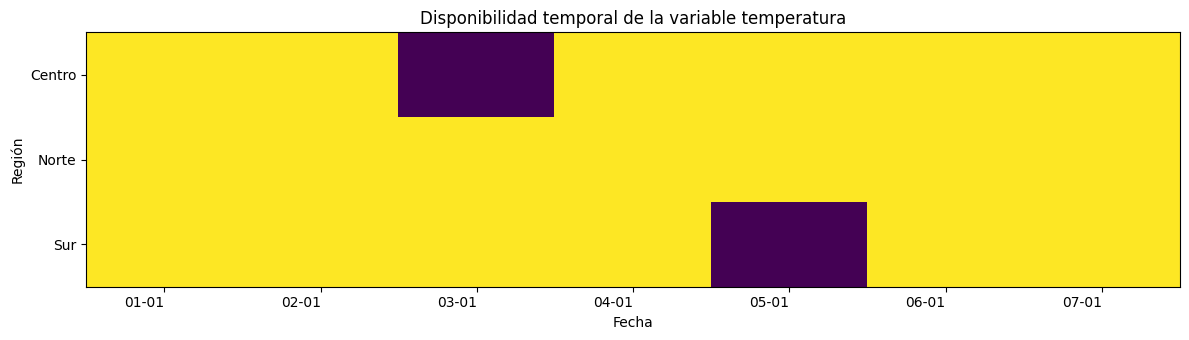

In [66]:
fig, ax = plt.subplots(figsize=(12, 3.5))

imagen = ax.imshow(
    matriz_disponibilidad.values,
    aspect="auto"
)


ax.set_yticks(
    np.arange(len(matriz_disponibilidad.index))
)

ax.set_yticklabels(
    matriz_disponibilidad.index
)

ax.set_xticks(
    np.arange(len(matriz_disponibilidad.columns))
)

ax.set_xticklabels(
    [
        fecha.strftime("%d-%m")
        for fecha in matriz_disponibilidad.columns
    ],
    ha="right"
)

ax.set_xlabel("Fecha")
ax.set_ylabel("Región")
ax.set_title(
    "Disponibilidad temporal de la variable temperatura"
)

plt.tight_layout()
plt.show()